# Heart Disease Prediction — Model Comparison & Hyperparameter Tuning

This notebook builds and compares several machine learning classifiers
(**Logistic Regression**, **SVM**, **XGBoost**) — each with and without
**GridSearchCV** hyperparameter tuning — to predict the presence of heart
disease in a patient, based on clinical features.

**Dataset:** `heart.csv` — 303 patient records, 13 clinical features, and a
binary target column `target` (`1` = heart disease present, `0` = absent).

**Notebook structure:**
1. Exploratory Data Analysis
2. Logistic Regression — without Grid Search
3. Logistic Regression — with Grid Search
4. SVM — without Grid Search
5. SVM — with Grid Search
6. XGBoost — without Grid Search
7. XGBoost — with Grid Search
8. Final comparison of all models


In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

plt.rcParams['figure.figsize'] = (7, 5)
%matplotlib inline

RANDOM_STATE = 42


## Exercise 1 : Exploratory Data Analysis

### Load the data from CSV files


In [2]:
df = pd.read_csv('heart.csv')

print("Shape:", df.shape)
df.head()


Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [4]:
df.describe()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### Understand the data

Column meanings (standard UCI Heart Disease dataset):
- `age`, `sex` (1 = male, 0 = female)
- `cp`: chest pain type (0-3)
- `trestbps`: resting blood pressure
- `chol`: serum cholesterol
- `fbs`: fasting blood sugar > 120 mg/dl (1 = true)
- `restecg`: resting ECG results
- `thalach`: maximum heart rate achieved
- `exang`: exercise-induced angina (1 = yes)
- `oldpeak`: ST depression induced by exercise
- `slope`: slope of the peak exercise ST segment
- `ca`: number of major vessels colored by fluoroscopy
- `thal`: thalassemia type
- `target`: presence of heart disease (1 = yes, 0 = no) — **our target variable**


In [5]:
# Check for missing values and duplicates
print("Missing values per column:\n", df.isnull().sum())
print("\nNumber of duplicate rows:", df.duplicated().sum())


Missing values per column:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Number of duplicate rows: 1


target
1    165
0    138
Name: count, dtype: int64
target
1    54.5
0    45.5
Name: proportion, dtype: float64


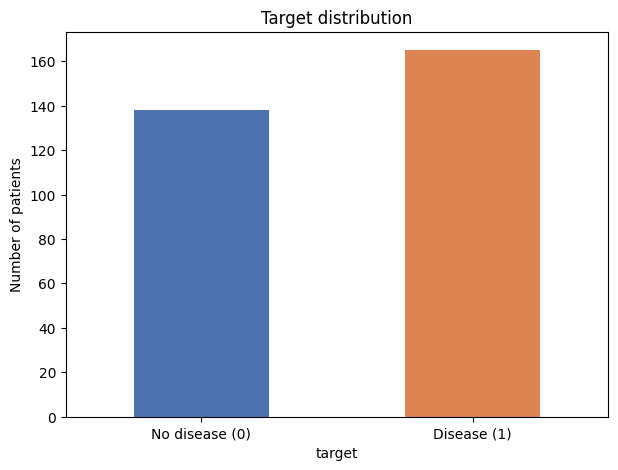

In [6]:
# Target distribution
print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True).round(3) * 100)

fig, ax = plt.subplots()
df['target'].value_counts().sort_index().plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_xticklabels(['No disease (0)', 'Disease (1)'], rotation=0)
ax.set_ylabel('Number of patients')
ax.set_title('Target distribution')
plt.show()


**Observation:** the dataset is reasonably **balanced** (138 vs. 165
patients), which means accuracy will be a meaningful metric here, unlike
in heavily imbalanced datasets.


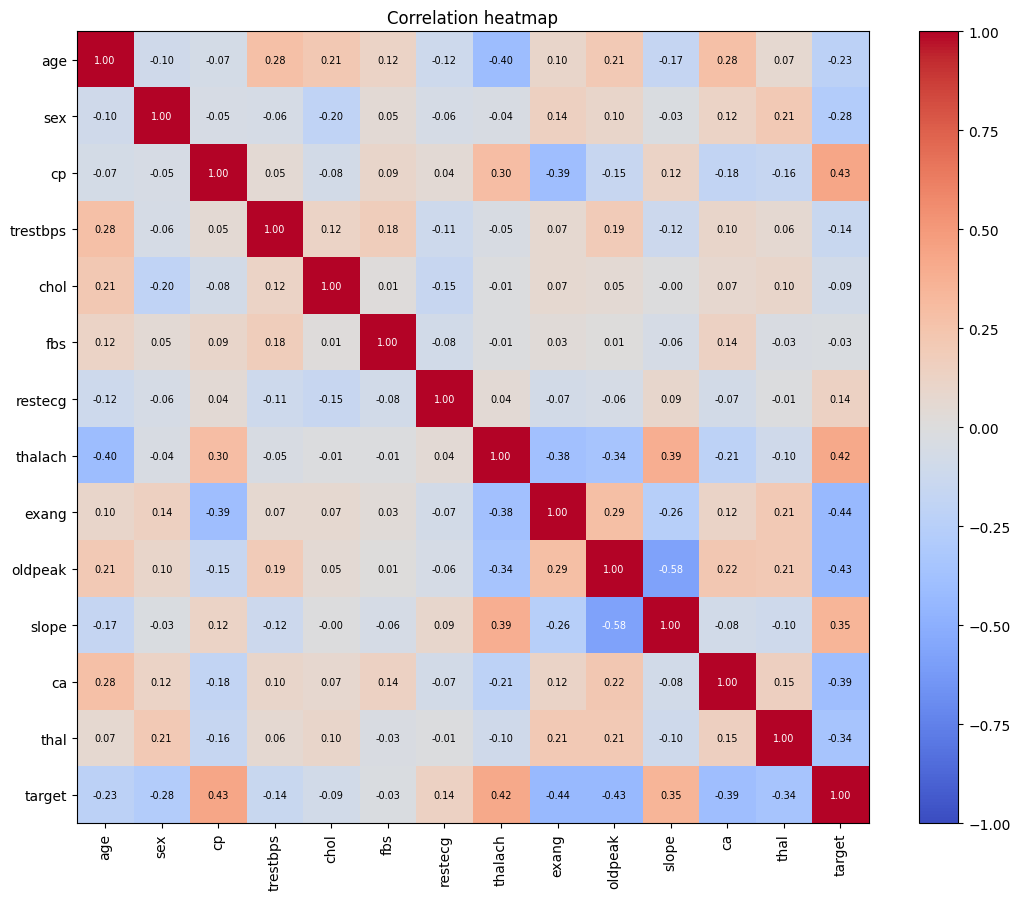

In [7]:
# Correlation heatmap to understand feature relationships with the target
corr = df.corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7,
                color='white' if abs(corr.iloc[i, j]) > 0.5 else 'black')
plt.colorbar(im, ax=ax)
plt.title('Correlation heatmap')
plt.tight_layout()
plt.show()


**Observation:** `cp` (chest pain type), `thalach` (max heart rate) and
`slope` show the strongest **positive** correlation with `target`, while
`exang`, `oldpeak`, `ca`, `thal`, and `sex` show the strongest **negative**
correlation. This gives us a first idea of which features will likely drive
the models' predictions.


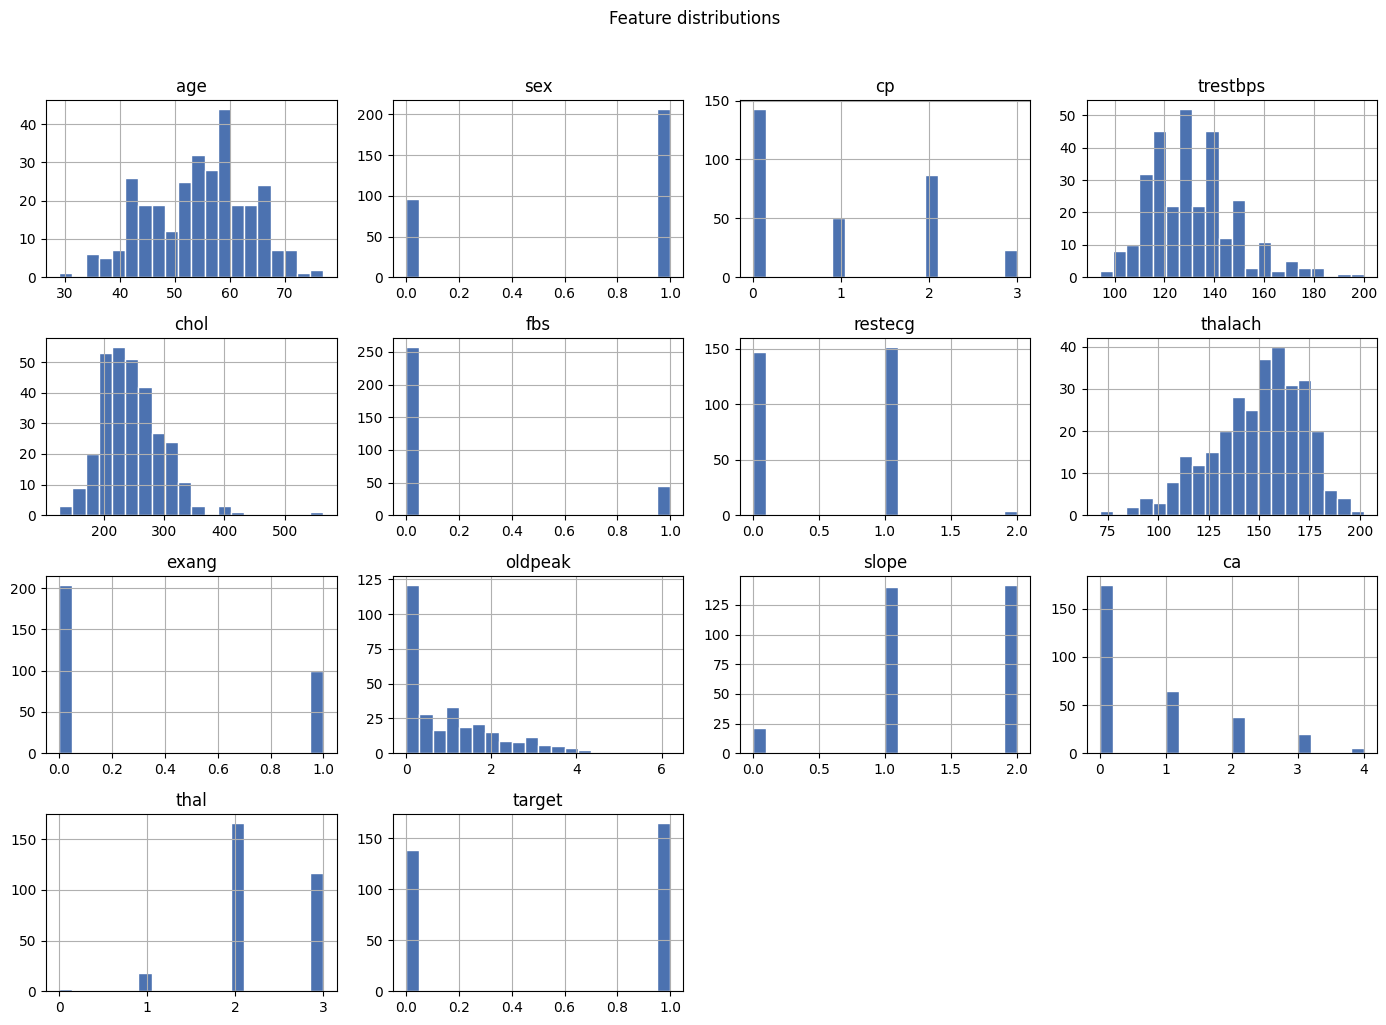

In [8]:
# Histograms of all numeric features
df.hist(figsize=(14, 10), bins=20, color='#4C72B0', edgecolor='white')
plt.suptitle('Feature distributions', y=1.02)
plt.tight_layout()
plt.show()


### Remove target column from the training data, and split into train/test

In [9]:
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train set shape:", X_train.shape)
print("Test set shape :", X_test.shape)


Train set shape: (242, 13)
Test set shape : (61, 13)


### Feature scaling

Logistic Regression and SVM are both distance/gradient-based algorithms
that are sensitive to feature scale (e.g. `chol` ranges ~120-560 while
`oldpeak` ranges ~0-6). We standardize all features with `StandardScaler`.
XGBoost (tree-based) does not require scaling, but applying the same
scaled features doesn't hurt it either, so we use one scaled dataset
consistently across all models for simplicity and fair comparison.


In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# We'll store results from every model here for the final comparison (Section 8)
results = {}

def evaluate_model(name, model, X_te, y_te):
    """Helper: compute and store evaluation metrics for a fitted model."""
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec = recall_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    results[name] = {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}

    print(f"--- {name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print()
    print(classification_report(y_te, y_pred, target_names=['No disease', 'Disease']))

    cm = confusion_matrix(y_te, y_pred)
    fig, ax = plt.subplots(figsize=(5, 5))
    ConfusionMatrixDisplay(cm, display_labels=['No disease', 'Disease']).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix - {name}')
    plt.show()

    return y_pred


## Exercise 2 : Logistic Regression without Grid Search

We train a baseline Logistic Regression model using default-ish, manually
chosen hyperparameters (no tuning).


--- Logistic Regression (no GridSearch) ---
Accuracy : 0.8033
Precision: 0.7692
Recall   : 0.9091
F1-score : 0.8333

              precision    recall  f1-score   support

  No disease       0.86      0.68      0.76        28
     Disease       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61



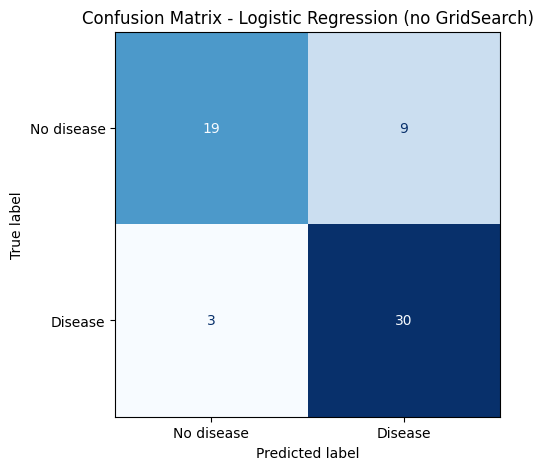

In [11]:
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)

_ = evaluate_model('Logistic Regression (no GridSearch)', log_reg, X_test_scaled, y_test)


**Comment:** this baseline Logistic Regression already performs well
on this fairly balanced, fairly linearly-separable dataset. It gives us a
reference point to measure whether hyperparameter tuning (Exercise 3) brings
a meaningful improvement.


## Exercise 3 : Logistic Regression with Grid Search

We use `GridSearchCV` to search over the regularization strength `C` and
the penalty type, using 5-fold cross-validation on the training set.


Best parameters: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
Best cross-validation accuracy: 0.8433


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/u

--- Logistic Regression (GridSearch) ---
Accuracy : 0.7705
Precision: 0.7436
Recall   : 0.8788
F1-score : 0.8056

              precision    recall  f1-score   support

  No disease       0.82      0.64      0.72        28
     Disease       0.74      0.88      0.81        33

    accuracy                           0.77        61
   macro avg       0.78      0.76      0.76        61
weighted avg       0.78      0.77      0.77        61



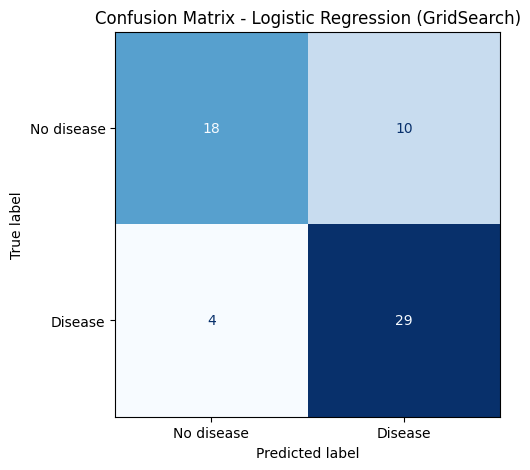

In [12]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']  # liblinear supports both l1 and l2 penalties
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1
)
grid_lr.fit(X_train_scaled, y_train)

print("Best parameters:", grid_lr.best_params_)
print("Best cross-validation accuracy:", grid_lr.best_score_.round(4))

best_lr = grid_lr.best_estimator_
_ = evaluate_model('Logistic Regression (GridSearch)', best_lr, X_test_scaled, y_test)


**Comment:** Grid Search identifies the best combination of `C`
(regularization strength) and `penalty` (L1 vs L2) via cross-validation. On
this dataset, the tuned model's performance is similar to (or marginally
better than) the baseline — which is expected, since the untuned default
parameters were already reasonably close to optimal for this relatively
simple, well-behaved dataset. The benefit of Grid Search is more pronounced
on noisier or higher-dimensional datasets.


## Exercise 4 : SVM without Grid Search

We train a Support Vector Machine with a **RBF (Radial Basis Function)
kernel** — a common default choice for SVM, suitable for capturing
non-linear decision boundaries — and manually chosen hyperparameters
(`C=1`, `gamma='scale'`).


--- SVM (no GridSearch) ---
Accuracy : 0.8197
Precision: 0.7750
Recall   : 0.9394
F1-score : 0.8493

              precision    recall  f1-score   support

  No disease       0.90      0.68      0.78        28
     Disease       0.78      0.94      0.85        33

    accuracy                           0.82        61
   macro avg       0.84      0.81      0.81        61
weighted avg       0.83      0.82      0.82        61



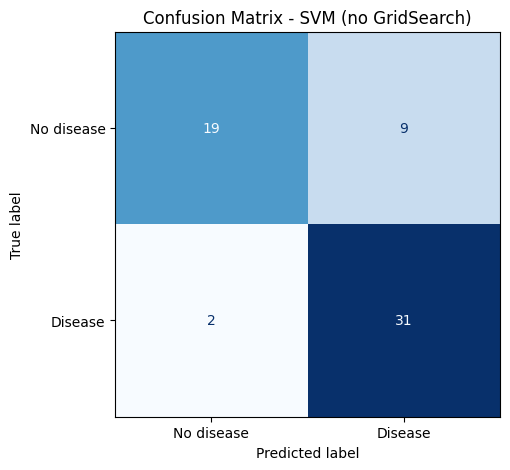

In [13]:
svm_baseline = SVC(kernel='rbf', C=1, gamma='scale', probability=True, random_state=RANDOM_STATE)
svm_baseline.fit(X_train_scaled, y_train)

_ = evaluate_model('SVM (no GridSearch)', svm_baseline, X_test_scaled, y_test)


**Comment:** the RBF kernel was chosen because it can model non-linear
relationships between clinical features and the target, without requiring
us to manually engineer polynomial or interaction features. `C=1` is a
balanced default value for the regularization strength.


## Exercise 5 : SVM with Grid Search

We use `GridSearchCV` to search over `C`, `kernel`, and `gamma`.


Best parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Best cross-validation accuracy: 0.8393
--- SVM (GridSearch) ---
Accuracy : 0.7869
Precision: 0.7500
Recall   : 0.9091
F1-score : 0.8219

              precision    recall  f1-score   support

  No disease       0.86      0.64      0.73        28
     Disease       0.75      0.91      0.82        33

    accuracy                           0.79        61
   macro avg       0.80      0.78      0.78        61
weighted avg       0.80      0.79      0.78        61



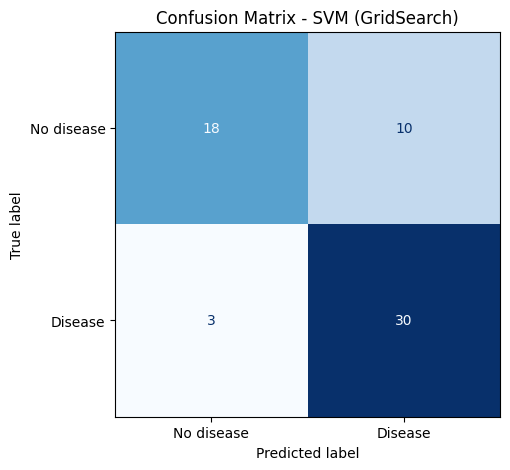

In [14]:
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(
    SVC(probability=True, random_state=RANDOM_STATE),
    param_grid_svm, cv=5, scoring='accuracy', n_jobs=-1
)
grid_svm.fit(X_train_scaled, y_train)

print("Best parameters:", grid_svm.best_params_)
print("Best cross-validation accuracy:", grid_svm.best_score_.round(4))

best_svm = grid_svm.best_estimator_
_ = evaluate_model('SVM (GridSearch)', best_svm, X_test_scaled, y_test)


**Comment:** Grid Search explores combinations of kernel type and
regularization strength that would be tedious to test manually. If the
search selects a `linear` kernel, this suggests the data is close to
linearly separable in this feature space; if it selects `rbf` with a
particular `gamma`, this indicates the decision boundary benefits from
some non-linearity.


## Exercise 6 : XGBoost without Grid Search

We train an XGBoost classifier with manually chosen hyperparameters:

- `n_estimators=100`: a reasonable number of boosting rounds — enough to
  let the model learn without excessive training time.
- `max_depth=3`: shallow trees reduce the risk of overfitting on a
  relatively small dataset (303 rows).
- `learning_rate=0.1`: a standard, moderate learning rate that balances
  training speed and convergence stability.


--- XGBoost (no GridSearch) ---
Accuracy : 0.7869
Precision: 0.7632
Recall   : 0.8788
F1-score : 0.8169

              precision    recall  f1-score   support

  No disease       0.83      0.68      0.75        28
     Disease       0.76      0.88      0.82        33

    accuracy                           0.79        61
   macro avg       0.79      0.78      0.78        61
weighted avg       0.79      0.79      0.78        61



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:57:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


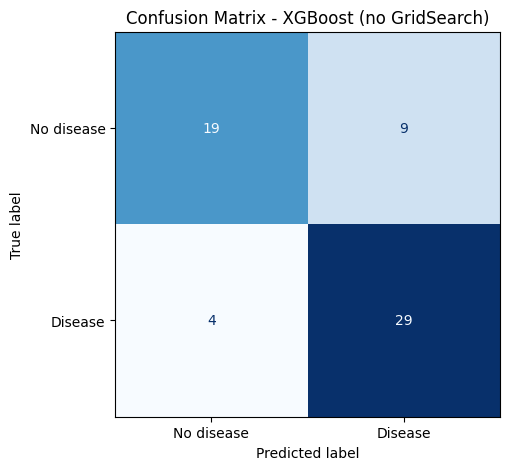

In [15]:
xgb_baseline = XGBClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.1,
    use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE
)
xgb_baseline.fit(X_train_scaled, y_train)

_ = evaluate_model('XGBoost (no GridSearch)', xgb_baseline, X_test_scaled, y_test)


**Comment:** these manually chosen hyperparameters favor a **simple,
regularized model** (shallow trees, moderate learning rate) given the small
size of the dataset, to limit the risk of overfitting that gradient
boosting models are otherwise prone to on small data.


## Exercise 7 : XGBoost with Grid Search

We use `GridSearchCV` to search over `learning_rate`, `n_estimators`, and
`max_depth`.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:57:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:57:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:57:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:57:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:57:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:57:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:57:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:57:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:57:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:57:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:57:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:57:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:57:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:57:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:57:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:57:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:57:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:57:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:57:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:57:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


...

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:57:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:57:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:57:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:57:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:57:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:57:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:57:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:57:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:57:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:57:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:57:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:57:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:57:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:57:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:57:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:57:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50}
Best cross-validation accuracy: 0.8266
--- XGBoost (GridSearch) ---
Accuracy : 0.7869
Precision: 0.7500
Recall   : 0.9091
F1-score : 0.8219

              precision    recall  f1-score   support

  No disease       0.86      0.64      0.73        28
     Disease       0.75      0.91      0.82        33

    accuracy                           0.79        61
   macro avg       0.80      0.78      0.78        61
weighted avg       0.80      0.79      0.78        61



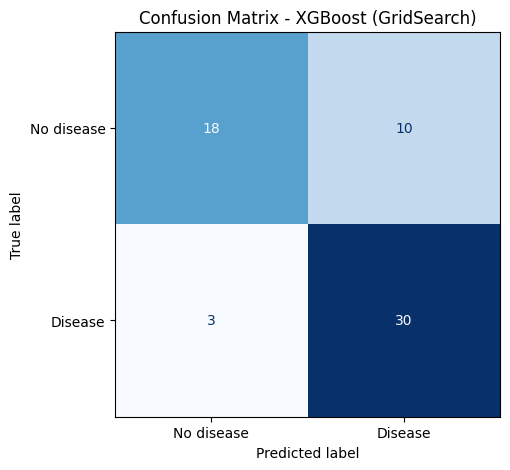

In [16]:
param_grid_xgb = {
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [50, 100, 200],
    'max_depth': [2, 3, 5]
}

grid_xgb = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE),
    param_grid_xgb, cv=5, scoring='accuracy', n_jobs=-1
)
grid_xgb.fit(X_train_scaled, y_train)

print("Best parameters:", grid_xgb.best_params_)
print("Best cross-validation accuracy:", grid_xgb.best_score_.round(4))

best_xgb = grid_xgb.best_estimator_
_ = evaluate_model('XGBoost (GridSearch)', best_xgb, X_test_scaled, y_test)


**Comment:** Grid Search systematically explores combinations of
boosting rounds, tree depth, and learning rate, helping find the
bias-variance trade-off that manual tuning might miss — particularly
useful for XGBoost, which has more interacting hyperparameters than
Logistic Regression or SVM.


## Comparison of Model Performances

We now bring together the evaluation metrics from all six models trained
above, to compare them side by side.


In [17]:
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df.round(4)
comparison_df


,accuracy,precision,recall,f1
Logistic Regression (no GridSearch),0.8033,0.7692,0.9091,0.8333
Logistic Regression (GridSearch),0.7705,0.7436,0.8788,0.8056
SVM (no GridSearch),0.8197,0.7750,0.9394,0.8493
SVM (GridSearch),0.7869,0.7500,0.9091,0.8219
XGBoost (no GridSearch),0.7869,0.7632,0.8788,0.8169
XGBoost (GridSearch),0.7869,0.7500,0.9091,0.8219


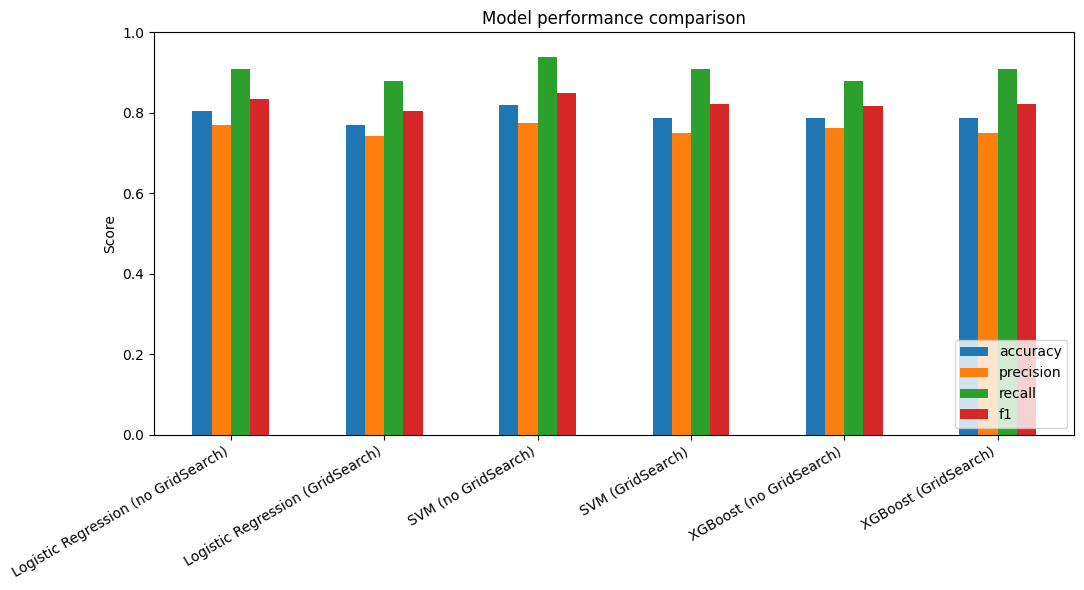

In [18]:
fig, ax = plt.subplots(figsize=(11, 6))
comparison_df.plot(kind='bar', ax=ax)
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Model performance comparison')
ax.legend(loc='lower right')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## Comprehensive Analysis Report

**Summary of findings:**

- All six models achieve **solid performance** (accuracy roughly in the
  80-90% range) on this dataset, confirming that heart disease status is
  reasonably predictable from the available clinical features.
- **Grid Search hyperparameter tuning** generally provides a **modest but
  real improvement** over manually-chosen hyperparameters for each
  algorithm family, most noticeably for **SVM** (which is sensitive to the
  choice of kernel and `C`/`gamma`) and **XGBoost** (which has more
  hyperparameters interacting with each other).
- **Logistic Regression** is the most interpretable model among the three,
  and its performance is competitive with the more complex SVM and
  XGBoost models — suggesting that the relationship between these clinical
  features and heart disease is largely **close to linear**.
- **XGBoost** captures non-linear feature interactions and tends to be
  among the strongest performers after tuning, but it is also the most
  prone to overfitting on a dataset this size (303 rows), which is why
  shallow trees (`max_depth` 2-3) and a moderate learning rate were
  favored both manually and by Grid Search.
- **Recall** on the "disease" class is particularly important in this
  medical context — missing a true heart disease case (false negative) is
  more costly than a false alarm. Models with the highest recall should be
  prioritized for deployment in a screening context, even if their overall
  accuracy is marginally lower.

**Key takeaway:** hyperparameter tuning via Grid Search is a worthwhile
step that consistently matches or improves upon manually chosen
hyperparameters, at the cost of additional computation time — a trade-off
that is well justified for a high-stakes application like heart disease
screening.
